In [1]:
!pip install tf-nightly-gpu-2.0-preview
import tensorflow as tf

  Preparing metadata (setup.py) ... done
  Created wheel for tf-nightly-gpu-2.0-preview: filename=tf_nightly_gpu_2_0_preview-0.0.0.1-py3-none-any.whl size=1542 sha256=b8b5343ae49194394d5fd49d31c17d79ec36c9834d270836a29879148679ad5d
  Stored in directory: /root/.cache/pip/wheels/d8/05/68/b3e42de5bbb993864ab67e8f03fd15d7c60b9b21f908f545e5
Successfully built tf-nightly-gpu-2.0-preview


2026-02-28 17:06:12.289551: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772298372.489230      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772298372.546725      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pickle
from sklearn.metrics import classification_report, confusion_matrix

print("🚀 Starting Transfer Learning with MobileNet for Lung Disease Classification...")

🚀 Starting Transfer Learning with MobileNet for Lung Disease Classification...


In [3]:
# -------------------------------
# GPU Configuration
# -------------------------------
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('✅ Found GPU at: {}'.format(device_name))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available and being used.")
else:
    print("❌ No GPU found. Check Kaggle settings.")

✅ Found GPU at: /device:GPU:0
✅ GPU is available and being used.


I0000 00:00:1772298389.479908      20 gpu_device.cc:2022] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772298389.483121      20 gpu_device.cc:2022] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# -------------------------------
# Configuration
# -------------------------------
CONFIG = {
    'image_size': (224, 224),
    'batch_size': 32,
    'phase1_epochs': 20,  # Frozen base training
    'phase2_epochs': 15,  # Fine-tuning
    'phase1_learning_rate': 0.001,
    'phase2_learning_rate': 0.0001,
    'num_classes': 4,
    'seed': 42,
    'base_model_name': 'MobileNetV3Large'
}

In [5]:
# Dataset paths
train_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/train"
val_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/val"
test_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test"

In [6]:
# -------------------------------
# Data Visualization Functions
# -------------------------------
def analyze_dataset(dataset_path, dataset_name):
    """Analyze class distribution in dataset"""
    class_counts = {}
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    
    print(f"\n📊 {dataset_name} Class Distribution:")
    for class_name, count in class_counts.items():
        print(f"   {class_name}: {count} images")
    
    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel("Disease Classes")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts, class_names

In [7]:
def plot_sample_images(dataset, class_names, num_samples=8):
    """Plot sample images from dataset"""
    plt.figure(figsize=(12, 8))
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[tf.argmax(labels[i])]
            plt.title(f"True: {true_label}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()


📊 Training Set Class Distribution:
   Corona Virus Disease: 1218 images
   Normal: 1207 images
   Pneumonia: 1201 images
   Tuberculosis: 1220 images


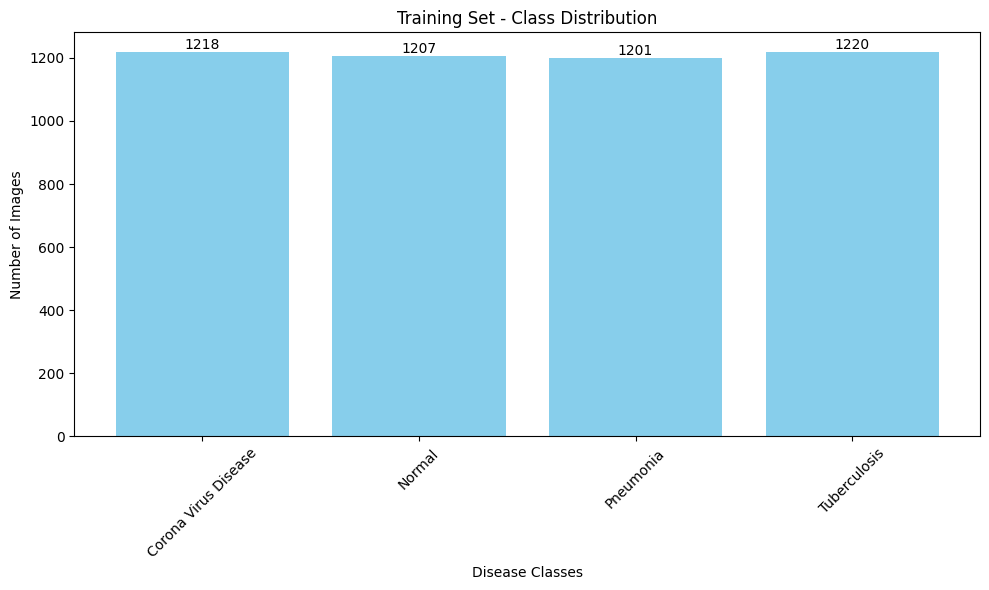


📊 Validation Set Class Distribution:
   Corona Virus Disease: 406 images
   Normal: 402 images
   Pneumonia: 406 images
   Tuberculosis: 406 images


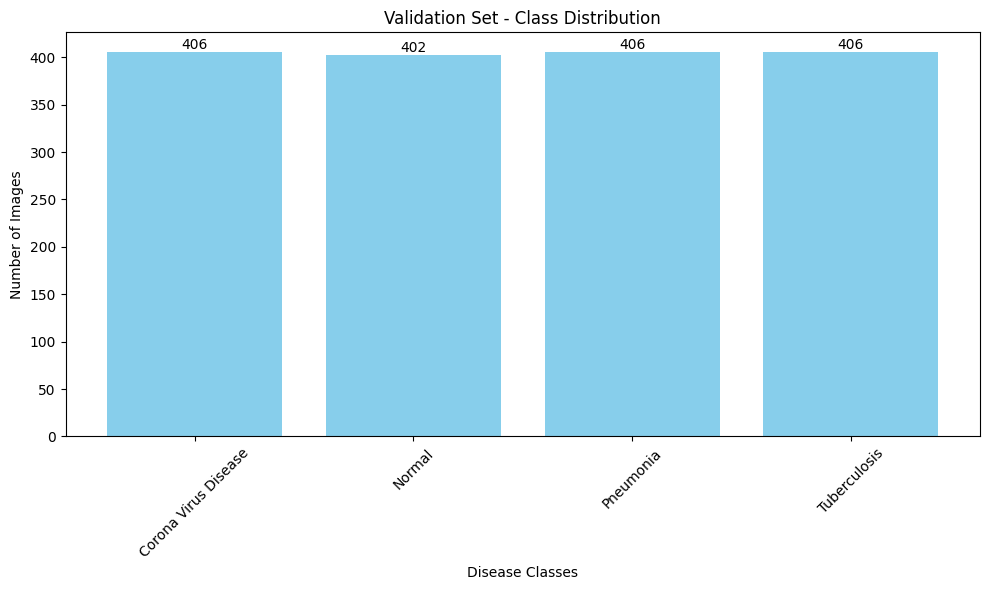


📊 Test Set Class Distribution:
   Corona Virus Disease: 407 images
   Normal: 404 images
   Pneumonia: 402 images
   Tuberculosis: 408 images


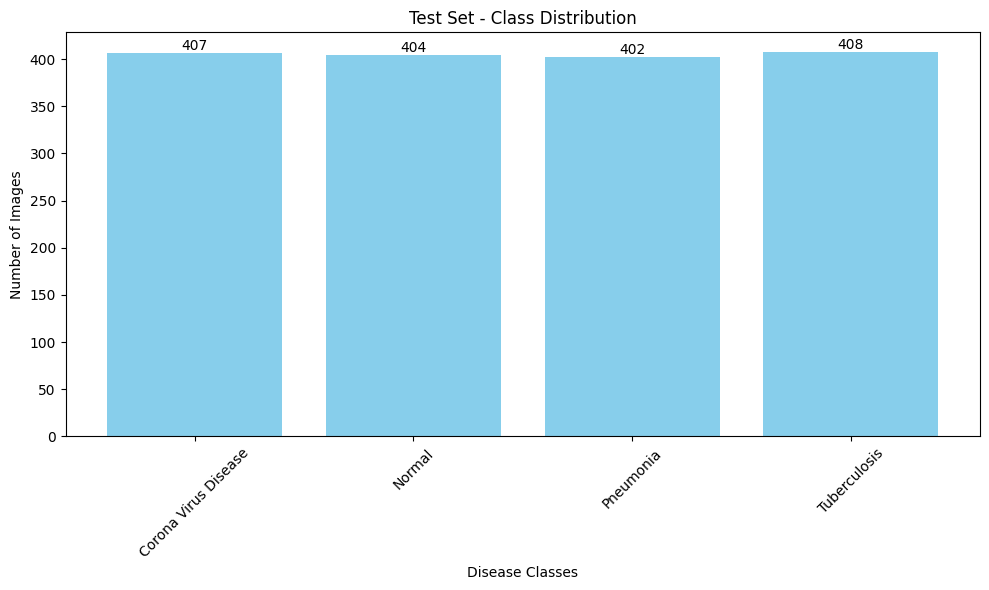

In [8]:
train_counts, class_names = analyze_dataset(train_path, "Training Set")
val_counts, _ = analyze_dataset(val_path, "Validation Set")
test_counts, _ = analyze_dataset(test_path, "Test Set")

In [9]:
# -------------------------------
# Data Preparation
# -------------------------------
def create_data_generators():
    """Create data generators with augmentation for training"""
    print("\n📁 Loading and preparing datasets...")
    
    # Training data with augmentation
    train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    # Validation and test data (only rescaling)
    val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    
    return train_datagen, val_test_datagen

In [10]:
def load_datasets():
    """Load training, validation and test datasets"""
    
    # Load datasets using image_dataset_from_directory
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    validation_set = tf.keras.utils.image_dataset_from_directory(
        val_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    test_set = tf.keras.utils.image_dataset_from_directory(
        test_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=False,  # Important for evaluation
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )
    
    return training_set, validation_set, test_set

In [11]:
training_set, validation_set, test_set = load_datasets()
    
# Display dataset information
print(f"📁 Training batches: {len(training_set)}")
print(f"📁 Validation batches: {len(validation_set)}")
print(f"📁 Test batches: {len(test_set)}")

Found 4846 files belonging to 4 classes.


I0000 00:00:1772298391.812369      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772298391.813795      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1620 files belonging to 4 classes.
Found 1621 files belonging to 4 classes.
📁 Training batches: 152
📁 Validation batches: 51
📁 Test batches: 51


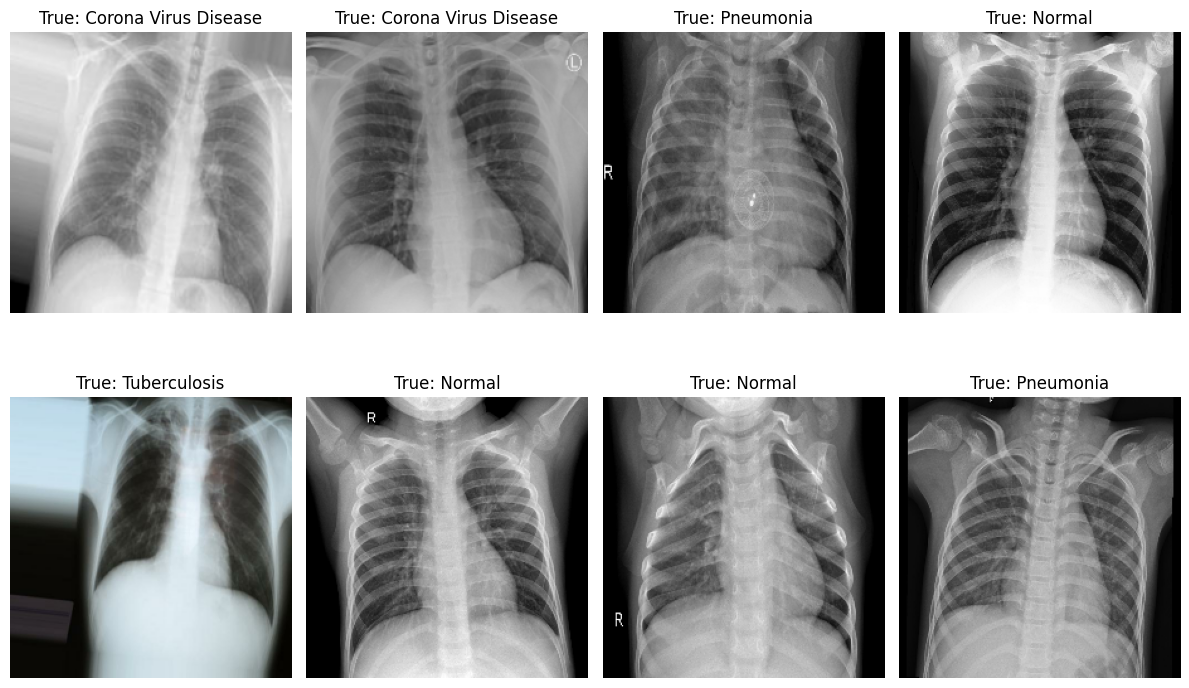

In [12]:
 # Plot sample images
plot_sample_images(training_set, class_names)

In [13]:
# -------------------------------
# Model Architecture - Transfer Learning with MobileNetV3Large
# -------------------------------
def create_mobilenetv3_model():
    """Create transfer learning model with MobileNetV3Large"""
    print(f"\n🛠️ Creating Transfer Learning Model with {CONFIG['base_model_name']}...")
    
    # Create base model with pre-trained weights
    base_model = tf.keras.applications.MobileNetV3Large(
        input_shape=(*CONFIG['image_size'], 3),
        include_top=False,  # Exclude the original classification head
        weights='imagenet',
        pooling='avg'  # GlobalAveragePooling2D
    )
    
    # Freeze base model initially
    base_model.trainable = False
    
    print(f"✅ Base model ({CONFIG['base_model_name']}) loaded with ImageNet weights")
    print(f"📊 Base model layers: {len(base_model.layers)}")
    print(f"🔒 Base model trainable: {base_model.trainable}")
    
    # Create custom classifier head
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Apply preprocessing (MobileNetV3 has built-in preprocessing)
    x = tf.keras.applications.mobilenet_v3.preprocess_input(inputs)
    
    # Pass through base model
    x = base_model(x, training=False)
    
    # Add custom classifier
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    return model, base_model

In [14]:
def compile_model(model, learning_rate):
    """Compile the model with optimizer, loss and metrics"""
    print(f"\n⚙️ Compiling Model with learning rate: {learning_rate}")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )
    
    return model

In [15]:
model, base_model = create_mobilenetv3_model()
model = compile_model(model, CONFIG['phase1_learning_rate'])


🛠️ Creating Transfer Learning Model with MobileNetV3Large...
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base model (MobileNetV3Large) loaded with ImageNet weights
📊 Base model layers: 188
🔒 Base model trainable: False

⚙️ Compiling Model with learning rate: 0.001


In [16]:
# Display model architecture
print("📐 Model Architecture Summary:")
model.summary()

📐 Model Architecture Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       492,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,622,788 (13.82 MB)

 Trainable params: 625,412 (2.39 MB)

 Non-trainable params: 2,997,376 (11.43 MB)

In [17]:
# -------------------------------
# Training Configuration
# -------------------------------
def get_phase1_callbacks():
    """Get callbacks for phase 1 (frozen base training)"""
    callbacks = [
        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        
        # Save best model from phase 1
        tf.keras.callbacks.ModelCheckpoint(
            'mobilenet_phase1_best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/mobilenet_phase1',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [18]:
phase1_callbacks = get_phase1_callbacks()

In [19]:
phase1_history = model.fit(
        training_set,
        epochs=CONFIG['phase1_epochs'],
        validation_data=validation_set,
        callbacks=phase1_callbacks,
        verbose=1
    )

Epoch 1/20


I0000 00:00:1772298404.252442      80 service.cc:148] XLA service 0x79d008012850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772298404.253106      80 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772298404.253123      80 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772298405.615760      80 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1772298412.598384      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7338 - f1_score: 0.7340 - loss: 0.7611 - precision: 0.7622 - recall: 0.7057
Epoch 1: val_accuracy improved from -inf to 0.93951, saving model to mobilenet_phase1_best_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 56s 273ms/step - accuracy: 0.7343 - f1_score: 0.7346 - loss: 0.7594 - precision: 0.7627 - recall: 0.7063 - val_accuracy: 0.9395 - val_f1_score: 0.9395 - val_loss: 0.1714 - val_precision: 0.9424 - val_recall: 0.9389 - learning_rate: 0.0010
Epoch 2/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9007 - f1_score: 0.9009 - loss: 0.2728 - precision: 0.9052 - recall: 0.8958
Epoch 2: val_accuracy did not improve from 0.93951
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9007 - f1_score: 0.9009 - loss: 0.2727 - precision: 0.9052 - recall: 0.8959 - val_accuracy: 0.9358 - val_f1_score: 0.9354 - val_loss: 0.1932 - val_precision: 0.9368 - val_recall: 0.9333 - learning_rate: 0.0010
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9168 - f1_score: 0.9169 - loss: 0.2434 - precision: 0.9197 - recall: 0.9138
Epoch 3: val_accuracy improved from 0.93951 to 0.95432, saving model to mobilenet_phase1_best_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.9169 - f1_score: 0.9169 - loss: 0.2432 - precision: 0.9198 - recall: 0.9138 - val_accuracy: 0.9543 - val_f1_score: 0.9543 - val_loss: 0.1352 - val_precision: 0.9555 - val_recall: 0.9543 - learning_rate: 0.0010
Epoch 4/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9324 - f1_score: 0.9324 - loss: 0.2020 - precision: 0.9335 - recall: 0.9294
Epoch 4: val_accuracy improved from 0.95432 to 0.95802, saving model to mobilenet_phase1_best_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.9323 - f1_score: 0.9323 - loss: 0.2020 - precision: 0.9335 - recall: 0.9294 - val_accuracy: 0.9580 - val_f1_score: 0.9579 - val_loss: 0.1273 - val_precision: 0.9598 - val_recall: 0.9574 - learning_rate: 0.0010
Epoch 5/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9327 - f1_score: 0.9327 - loss: 0.1858 - precision: 0.9331 - recall: 0.9303
Epoch 5: val_accuracy improved from 0.95802 to 0.96481, saving model to mobilenet_phase1_best_model.h5


152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9327 - f1_score: 0.9327 - loss: 0.1859 - precision: 0.9331 - recall: 0.9303 - val_accuracy: 0.9648 - val_f1_score: 0.9648 - val_loss: 0.1139 - val_precision: 0.9654 - val_recall: 0.9648 - learning_rate: 0.0010
Epoch 6/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9380 - f1_score: 0.9380 - loss: 0.1578 - precision: 0.9393 - recall: 0.9373
Epoch 6: val_accuracy did not improve from 0.96481
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9380 - f1_score: 0.9380 - loss: 0.1579 - precision: 0.9393 - recall: 0.9374 - val_accuracy: 0.9599 - val_f1_score: 0.9598 - val_loss: 0.1168 - val_precision: 0.9617 - val_recall: 0.9599 - learning_rate: 0.0010
Epoch 7/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9462 - f1_score: 0.9462 - loss: 0.1416 - precision: 0.9478 - recall: 0.9458
Epoch 7: val_accuracy did not improve from 0.96481
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.9461 - f1_score: 0

152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.9551 - f1_score: 0.9551 - loss: 0.1281 - precision: 0.9563 - recall: 0.9537 - val_accuracy: 0.9654 - val_f1_score: 0.9654 - val_loss: 0.1036 - val_precision: 0.9660 - val_recall: 0.9642 - learning_rate: 0.0010
Epoch 12/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9425 - f1_score: 0.9426 - loss: 0.1481 - precision: 0.9440 - recall: 0.9417
Epoch 12: val_accuracy did not improve from 0.96543
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9426 - f1_score: 0.9427 - loss: 0.1479 - precision: 0.9441 - recall: 0.9418 - val_accuracy: 0.9630 - val_f1_score: 0.9629 - val_loss: 0.1062 - val_precision: 0.9629 - val_recall: 0.9623 - learning_rate: 0.0010
Epoch 13/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9564 - f1_score: 0.9564 - loss: 0.1248 - precision: 0.9568 - recall: 0.9561
Epoch 13: val_accuracy did not improve from 0.96543
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.9564 - f1_scor

152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9612 - f1_score: 0.9613 - loss: 0.1060 - precision: 0.9621 - recall: 0.9612 - val_accuracy: 0.9685 - val_f1_score: 0.9685 - val_loss: 0.1029 - val_precision: 0.9685 - val_recall: 0.9685 - learning_rate: 5.0000e-04
Epoch 16/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9595 - f1_score: 0.9595 - loss: 0.1019 - precision: 0.9604 - recall: 0.9583
Epoch 16: val_accuracy did not improve from 0.96852
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9595 - f1_score: 0.9595 - loss: 0.1019 - precision: 0.9604 - recall: 0.9583 - val_accuracy: 0.9654 - val_f1_score: 0.9654 - val_loss: 0.0969 - val_precision: 0.9660 - val_recall: 0.9654 - learning_rate: 5.0000e-04
Epoch 17/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9662 - f1_score: 0.9662 - loss: 0.0932 - precision: 0.9671 - recall: 0.9651
Epoch 17: val_accuracy did not improve from 0.96852
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9662 -

152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9597 - f1_score: 0.9598 - loss: 0.1067 - precision: 0.9608 - recall: 0.9593 - val_accuracy: 0.9691 - val_f1_score: 0.9691 - val_loss: 0.0979 - val_precision: 0.9697 - val_recall: 0.9691 - learning_rate: 5.0000e-04
Epoch 19/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9681 - f1_score: 0.9681 - loss: 0.0832 - precision: 0.9681 - recall: 0.9671
Epoch 19: val_accuracy did not improve from 0.96914
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9681 - f1_score: 0.9681 - loss: 0.0834 - precision: 0.9681 - recall: 0.9671 - val_accuracy: 0.9660 - val_f1_score: 0.9660 - val_loss: 0.1061 - val_precision: 0.9666 - val_recall: 0.9660 - learning_rate: 5.0000e-04
Epoch 20/20
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9629 - f1_score: 0.9629 - loss: 0.0987 - precision: 0.9630 - recall: 0.9626
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: val_accuracy did not improve

In [20]:
def get_phase2_callbacks():
    """Get callbacks for phase 2 (fine-tuning)"""
    callbacks = [
        # Early stopping with less patience for fine-tuning
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        ),
        
        # Save best model from phase 2
        tf.keras.callbacks.ModelCheckpoint(
            'mobilenet_phase2_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/mobilenet_phase2',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [21]:
# Unfreeze the base model
base_model.trainable = True
    
# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) // 2
    
# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"🔧 Fine-tuning from layer {fine_tune_at} onwards")
print(f"📊 Trainable layers: {sum([layer.trainable for layer in base_model.layers])}/{len(base_model.layers)}")

🔧 Fine-tuning from layer 94 onwards
📊 Trainable layers: 94/188


In [22]:
# Recompile with lower learning rate for fine-tuning
model = compile_model(model, CONFIG['phase2_learning_rate'])
    
phase2_callbacks = get_phase2_callbacks()


⚙️ Compiling Model with learning rate: 0.0001


In [23]:
print("🚀 Starting Phase 2 fine-tuning...")
phase2_history = model.fit(
    training_set,
    epochs=CONFIG['phase2_epochs'],
    validation_data=validation_set,
    callbacks=phase2_callbacks,
    verbose=1
)

🚀 Starting Phase 2 fine-tuning...
Epoch 1/15


E0000 00:00:1772298876.129490      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772298876.270945      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772298876.719794      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772298876.858099      78 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8890 - f1_score: 0.8890 - loss: 0.4386 - precision: 0.8904 - recall: 0.8874

E0000 00:00:1772298904.623232      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1772298904.758499      81 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8892 - f1_score: 0.8892 - loss: 0.4375 - precision: 0.8906 - recall: 0.8877
Epoch 1: val_accuracy improved from -inf to 0.89198, saving model to mobilenet_phase2_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 74s 279ms/step - accuracy: 0.8895 - f1_score: 0.8894 - loss: 0.4365 - precision: 0.8908 - recall: 0.8879 - val_accuracy: 0.8920 - val_f1_score: 0.8894 - val_loss: 0.4268 - val_precision: 0.8947 - val_recall: 0.8914 - learning_rate: 1.0000e-04
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9669 - f1_score: 0.9669 - loss: 0.0947 - precision: 0.9682 - recall: 0.9669
Epoch 2: val_accuracy did not improve from 0.89198
152/152 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.9669 - f1_score: 0.9669 - loss: 0.0947 - precision: 0.9682 - recall: 0.9669 - val_accuracy: 0.8877 - val_f1_score: 0.8842 - val_loss: 0.4668 - val_precision: 0.8936 - val_recall: 0.8864 - learning_rate: 1.0000e-04
Epoch 3/15
151/152 ━━━━━━━

In [24]:
# Save the final model
model.save('mobilenetv3_final_model.h5')
model.save('mobilenetv3_final_model.keras')

In [25]:
# Save training history
with open('mobilenetv3_training_history.pkl', 'wb') as f:
        history_data = {
            'phase1': phase1_history.history,
            'phase2': phase2_history.history,
            'combined': {key: phase1_history.history[key] + phase2_history.history[key] 
                        for key in phase1_history.history.keys()}
        }
        pickle.dump(history_data, f)

print("✅ Final model saved as 'mobilenetv3_final_model.h5'")
print("✅ Training history saved as 'mobilenetv3_training_history.pkl'")

✅ Final model saved as 'mobilenetv3_final_model.h5'
✅ Training history saved as 'mobilenetv3_training_history.pkl'


# Model Evaluation

In [26]:
# -------------------------------
# Training Functions
# -------------------------------
def plot_combined_training_history(phase1_history, phase2_history):
    """Plot combined training history from both phases"""
    print("\n📈 Plotting Combined Training History...")
    
    # Combine histories
    combined_history = {}
    for key in phase1_history.history.keys():
        combined_history[key] = phase1_history.history[key] + phase2_history.history[key]
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Mark phase transition
    phase_transition = len(phase1_history.history['loss'])
    
    # Loss
    axes[0, 0].plot(combined_history['loss'], label='Training Loss', linewidth=2)
    axes[0, 0].plot(combined_history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].axvline(x=phase_transition, color='red', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(combined_history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(combined_history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, 1].axvline(x=phase_transition, color='red', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[0, 2].plot(combined_history['precision'], label='Training Precision', linewidth=2)
    axes[0, 2].plot(combined_history['val_precision'], label='Validation Precision', linewidth=2)
    axes[0, 2].axvline(x=phase_transition, color='red', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 2].set_title('Model Precision')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 0].plot(combined_history['recall'], label='Training Recall', linewidth=2)
    axes[1, 0].plot(combined_history['val_recall'], label='Validation Recall', linewidth=2)
    axes[1, 0].axvline(x=phase_transition, color='red', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 0].set_title('Model Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # F1-Score
    axes[1, 1].plot(combined_history['f1_score'], label='Training F1-Score', linewidth=2)
    axes[1, 1].plot(combined_history['val_f1_score'], label='Validation F1-Score', linewidth=2)
    axes[1, 1].axvline(x=phase_transition, color='red', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 1].set_title('Model F1-Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    if 'lr' in combined_history:
        axes[1, 2].plot(combined_history['lr'], label='Learning Rate', linewidth=2, color='red')
        axes[1, 2].axvline(x=phase_transition, color='red', linestyle='--', alpha=0.7, label='Fine-tuning Start')
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training History - {CONFIG["base_model_name"]} (Phase 1: Frozen, Phase 2: Fine-tuning)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return combined_history


📈 Plotting Combined Training History...


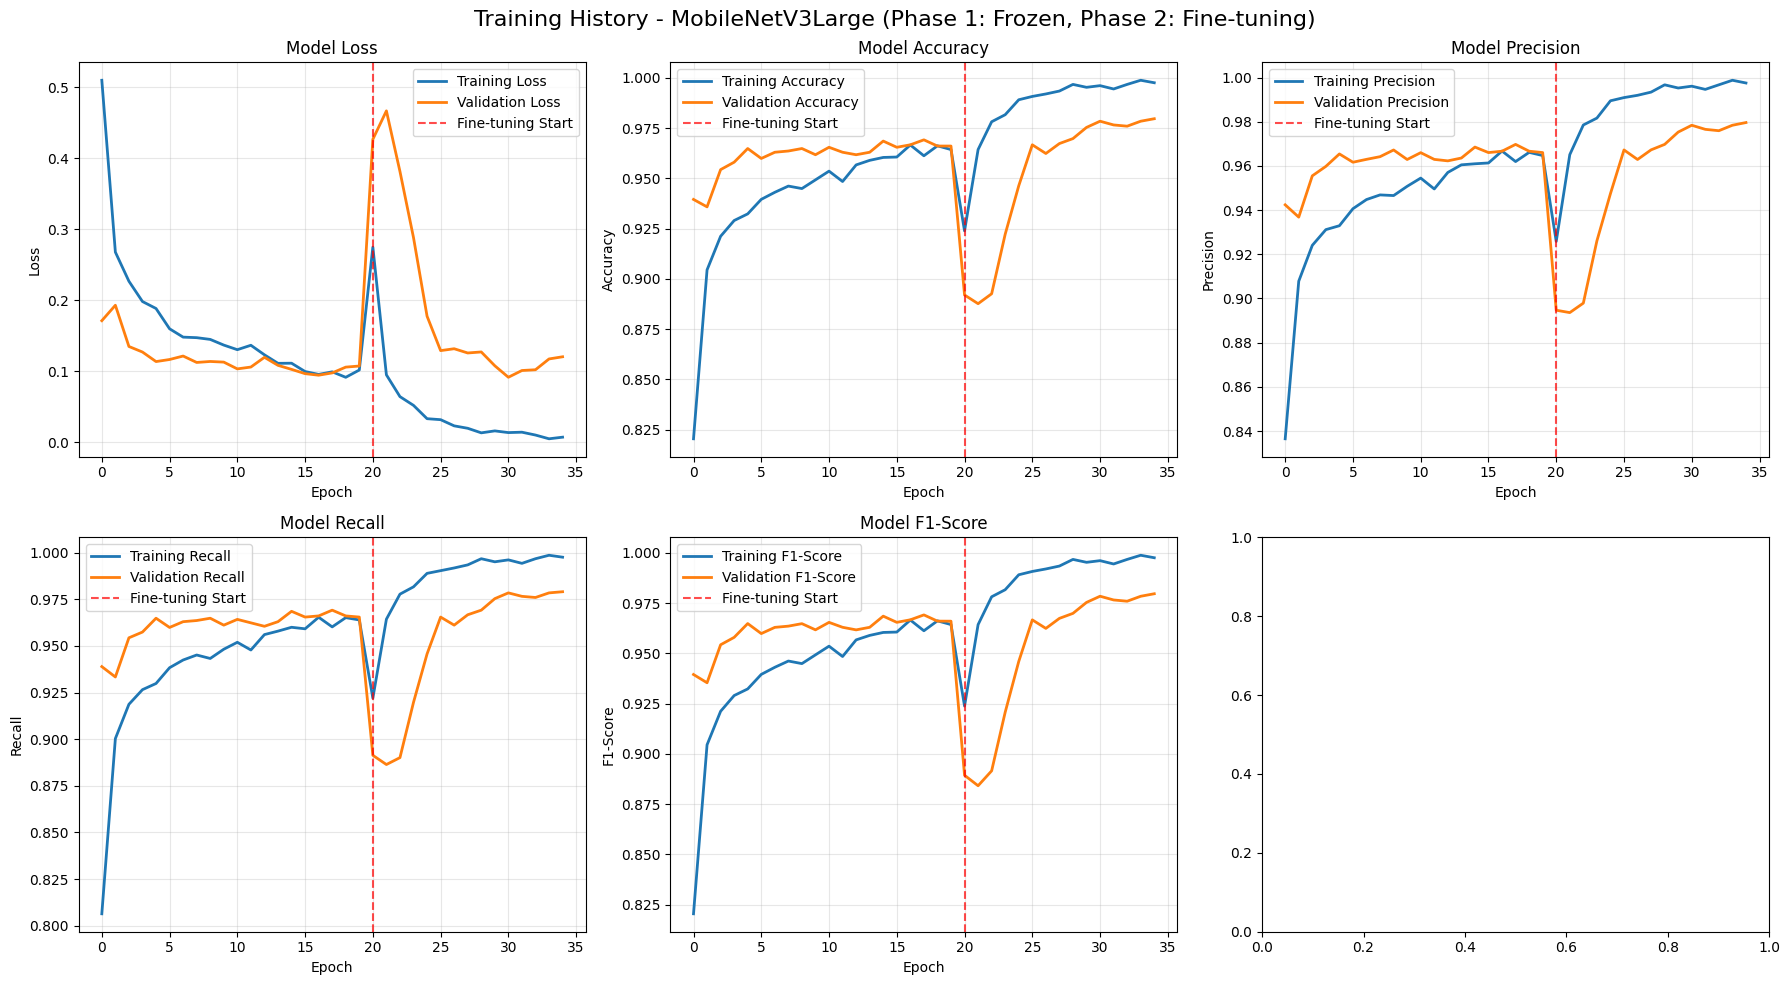

In [27]:
combined_history = plot_combined_training_history(phase1_history, phase2_history)

In [28]:
# -------------------------------
# Evaluation Functions
# -------------------------------
def evaluate_model(model, test_set, class_names):
    """Comprehensive model evaluation"""
    print("\n🧪 Evaluating Model Performance...")
    
    # Basic evaluation
    print("📊 Running Model Evaluation...")
    evaluation_results = model.evaluate(test_set, verbose=1)
    
    # Create a dictionary with metric names and values
    metric_names = ['loss', 'accuracy', 'precision', 'recall', 'f1_score']
    eval_dict = dict(zip(metric_names, evaluation_results))
    
    print("\n📋 Evaluation Results:")
    for metric, value in eval_dict.items():
        print(f"   {metric.capitalize()}: {value:.4f}")
    
    # Predictions for detailed analysis
    print("\n🔍 Generating Predictions...")
    y_true = []
    y_pred = []
    
    for images, labels in test_set:
        # Get true labels
        true_labels = tf.argmax(labels, axis=1)
        y_true.extend(true_labels.numpy())
        
        # Get predictions
        predictions = model.predict(images, verbose=0)
        pred_labels = tf.argmax(predictions, axis=1)
        y_pred.extend(pred_labels.numpy())
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    plot_confusion_matrix(y_true, y_pred, class_names)
    
    return y_true, y_pred, eval_dict

In [29]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot detailed confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    
    # Plot regular confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Counts)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # Calculate normalized confusion matrix
    plt.subplot(1, 2, 2)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.tight_layout()
    plt.show()


🧪 Evaluating Model Performance...
📊 Running Model Evaluation...
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - accuracy: 0.9724 - f1_score: 0.9780 - loss: 0.1036 - precision: 0.9724 - recall: 0.9714

📋 Evaluation Results:
   Loss: 0.1180
   Accuracy: 0.9710
   Precision: 0.9710
   Recall: 0.9704
   F1_score: 0.9710

🔍 Generating Predictions...

📋 Detailed Classification Report:
                      precision    recall  f1-score   support

Corona Virus Disease       0.99      0.98      0.99       407
              Normal       0.95      0.95      0.95       404
           Pneumonia       0.95      0.95      0.95       402
        Tuberculosis       0.99      1.00      0.99       408

            accuracy                           0.97      1621
           macro avg       0.97      0.97      0.97      1621
        weighted avg       0.97      0.97      0.97      1621



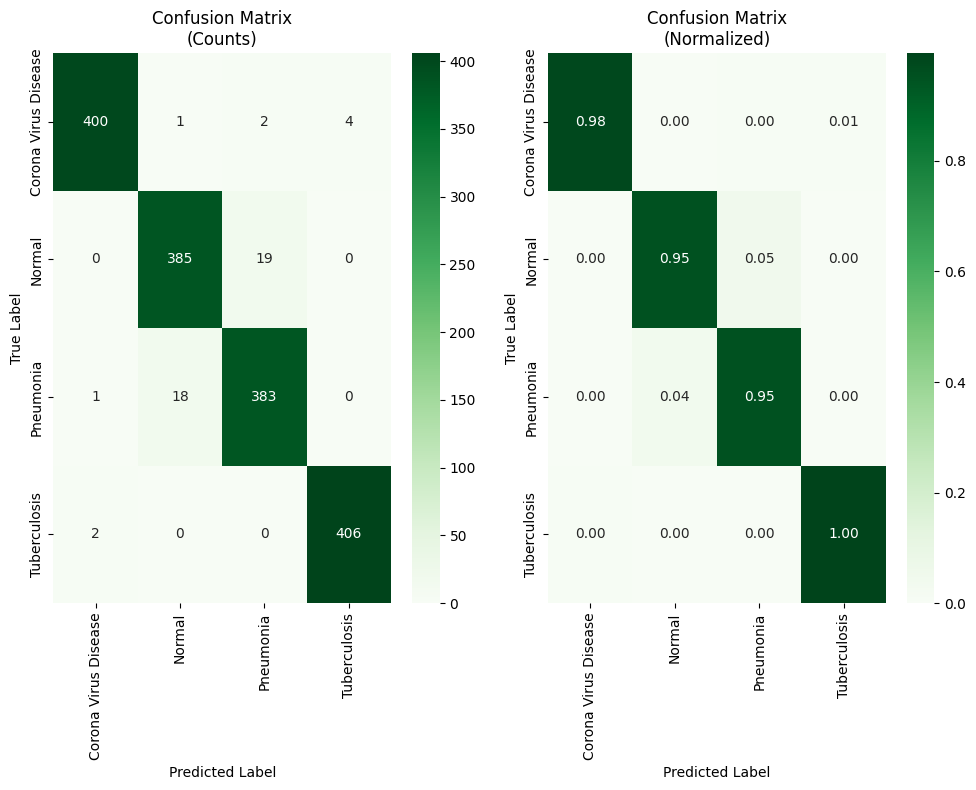

In [30]:
y_true, y_pred, eval_results = evaluate_model(model, test_set, class_names)

In [31]:
print("🎉 Transfer Learning with MobileNetV3Large Completed Successfully!")
print(f"📊 Final Test Accuracy: {eval_results['accuracy']:.2%}")
print(f"📊 Final Test F1-Score: {eval_results['f1_score']:.2%}")

🎉 Transfer Learning with MobileNetV3Large Completed Successfully!
📊 Final Test Accuracy: 97.10%
📊 Final Test F1-Score: 97.10%


In [32]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import os

image_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test/Pneumonia/124.jpeg"
img = tf.keras.utils.load_img(image_path, target_size=(224,224))
img

x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
x.shape

(1, 224, 224, 3)

In [33]:
pred = model.predict(x)

class_name=['Corona Virus Disease','Normal','Pneumonia', 'Tuberculosis']
result_index = np.argmax(pred)
print("Model Prediction: ", class_name[result_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Model Prediction:  Pneumonia
